# Fakenew TSV and preprocessing-stage statistics

This notebook profiles the consolidated TSV (defaults to **`data/processed/images/fakenews.tsv`** if present after image fetch, else **`data/fakenews.tsv`**) and related **preprocessing** artefacts:

- **Consolidated TSV**: column-level stats, duplicates, splits, labels, `image_ref` / optional `image_geo_blocked` coverage.
- **FakeNewsNet (FNN)**: index CSV row counts vs succeeded `news content.json` vs **`crawl_failures.jsonl`** (events and unique ids by reason and split).
- **Fakeddit**: multimodal source TSVs under **`data/processed/fakeddit/v2_text_metadata/`** — row counts, missing `image_url` / `hasImage`, label and split distribution.

- **Image fetch** (section 6): working **`data/processed/images/fakenews.tsv`**, `image_download_ok` / `image_geo_blocked`, `image_progress.jsonl`, on-disk file checks and sample thumbnails.

**Convention:** the first code cell sets the project **`ROOT`**. If the kernel cwd is **`notebooks/`**, it moves up one level.

**Dependencies:** `pandas`, `matplotlib`, `seaborn` (`requirements.txt`); optional `Pillow` for section 6 thumbnails.

In [1]:
import json
import os
import sys
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Project root (notebook in notebooks/ or cwd already root)
_cwd = Path.cwd()
ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
if not (ROOT / "data").is_dir():
    ROOT = _cwd  # fallback
os.chdir(ROOT)
print("ROOT =", ROOT.resolve())

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 4)

ROOT = C:\Users\mpcon\MSC Project


## 1. Optional: regenerate `fakenews.tsv`

Run from a terminal if you want a fresh consolidated file:

`python pipeline/04_consolidate_fakenews_tsv.py all` (only if you add that script locally; otherwise build `fakenews.tsv` per `pipeline/DATASETS_OVERVIEW.md` §7.2)

Or uncomment and run:

In [2]:
# import subprocess
# subprocess.run([sys.executable, str(ROOT / "pipeline" / "04_consolidate_fakenews_tsv.py"), "all"], check=True)

## 2. `fakenews.tsv` — all rows, all columns

Loads the full consolidated TSV (expect ~700k rows; ~1–2 GB RAM depending on environment).

In [3]:
_p_work = ROOT / "data" / "processed" / "images" / "fakenews.tsv"
FNEW = _p_work if _p_work.is_file() else (ROOT / "data" / "fakenews.tsv")
assert FNEW.is_file(), f"Missing {FNEW} — run 04_consolidate_fakenews_tsv.py all"

df = pd.read_csv(FNEW, sep="\t", dtype=str, low_memory=False)
print("rows:", len(df), "cols:", list(df.columns))
display(df.head(3))
display(df.info(memory_usage="deep"))

rows: 696676 cols: ['dataset', 'sample_id', 'split_official', 'domain', 'label_binary', 'label_fine', 'image_ref', 'has_image_ref', 'provenance']


,dataset,sample_id,split_official,domain,label_binary,label_fine,image_ref,has_image_ref,provenance
0,fakeddit,fd:awxhir,train,mildlyinteresting,1,0,https://external-preview.redd.it/WylDbZrnbvZdB...,true,data/processed/fakeddit/v2_text_metadata/multi...
1,fakeddit,fd:98pbid,train,pareidolia,0,2,https://preview.redd.it/wsfx0gp0f5h11.jpg?widt...,true,data/processed/fakeddit/v2_text_metadata/multi...
2,fakeddit,fd:6f2cy5,train,neutralnews,1,0,https://external-preview.redd.it/6fNhdbc6K1vFA...,true,data/processed/fakeddit/v2_text_metadata/multi...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 696676 entries, 0 to 696675
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   dataset         696676 non-null  object
 1   sample_id       696676 non-null  object
 2   split_official  682661 non-null  object
 3   domain          696676 non-null  object
 4   label_binary    696676 non-null  object
 5   label_fine      682661 non-null  object
 6   image_ref       694628 non-null  object
 7   has_image_ref   696676 non-null  object
 8   provenance      696676 non-null  object
dtypes: object(9)
memory usage: 448.4 MB


None

In [4]:
# Null / empty-string rates per column (preprocessing quality)
empty = {}
for c in df.columns:
    s = df[c].fillna("").astype(str).str.strip()
    empty[c] = {"null": int(df[c].isna().sum()), "empty_or_blank": int((s == "").sum())}
pd.DataFrame(empty).T

,null,empty_or_blank
dataset,0,0
sample_id,0,0
split_official,14015,14015
domain,0,0
label_binary,0,0
label_fine,14015,14015
image_ref,2048,2048
has_image_ref,0,0
provenance,0,0


In [5]:
# Duplicates and keys
dup_sid = df["sample_id"].duplicated().sum()
print("duplicate sample_id rows:", int(dup_sid))
for col in ["dataset", "split_official", "has_image_ref"]:
    if col in df.columns:
        display(df[col].value_counts(dropna=False))

df["has_image_ref_bool"] = df["has_image_ref"].str.lower().eq("true")
df.groupby("dataset")["has_image_ref_bool"].agg(["count", "sum", "mean"]).rename(columns={"sum": "with_image_ref", "mean": "rate"})

duplicate sample_id rows: 0


dataset
fakeddit       682661
fakenewsnet     14015
Name: count, dtype: int64

split_official
train         564000
validation     59342
test           59319
NaN            14015
Name: count, dtype: int64

has_image_ref
true     694628
false      2048
Name: count, dtype: int64

,count,with_image_ref,rate
dataset,,,
fakeddit,682661,680669,0.997082
fakenewsnet,14015,13959,0.996004


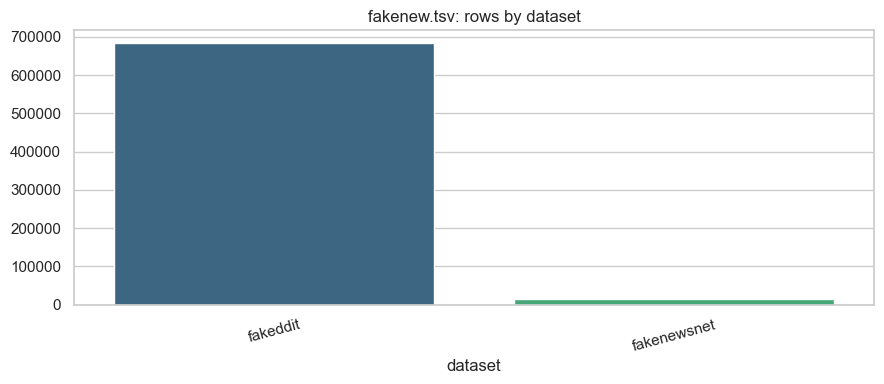

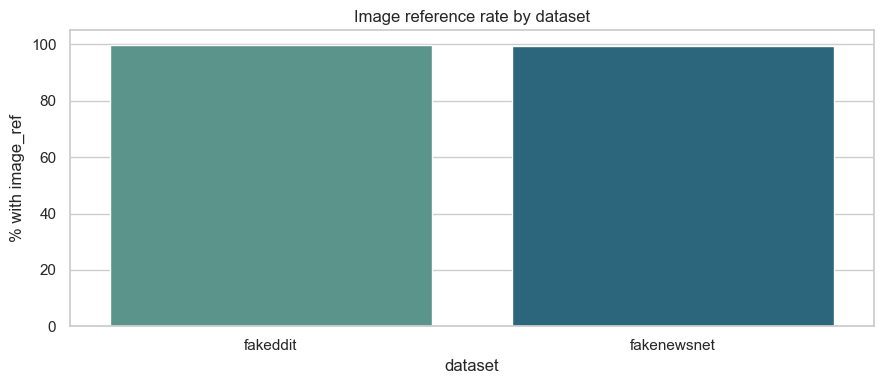

In [6]:
fig, ax = plt.subplots()
vc = df["dataset"].value_counts()
sns.barplot(x=vc.index, y=vc.values, ax=ax, hue=vc.index, palette="viridis", legend=False)
ax.set_title("fakenews.tsv: rows by dataset")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

rate = df.groupby("dataset")["has_image_ref_bool"].mean() * 100
fig, ax = plt.subplots()
sns.barplot(x=rate.index, y=rate.values, ax=ax, hue=rate.index, palette="crest", legend=False)
ax.set_ylim(0, 105)
ax.set_ylabel("% with image_ref")
ax.set_title("Image reference rate by dataset")
plt.tight_layout()
plt.show()

## 3. FakeNewsNet — preprocessing pipeline stats

Uses:

- **Index CSVs** in `pipeline/fakenewsnet/dataset/` (row counts per split).
- **Crawl output** `data/processed/fakenewsnet/` (count of `news content.json` per `source/label`).
- **`crawl_failures.jsonl`**: each line is one append event — **event counts** and **unique `news_id`** per `reason` and per `(news_source, label)`.

In [7]:
FNN_DATASET = ROOT / "pipeline" / "fakenewsnet" / "dataset"
FNN_COLLECTED = ROOT / "data" / "processed" / "fakenewsnet"
FAIL_LOG = FNN_COLLECTED / "crawl_failures.jsonl"

splits = [
    ("politifact", "fake"),
    ("politifact", "real"),
    ("gossipcop", "fake"),
    ("gossipcop", "real"),
]

def csv_rows(p: Path) -> int:
    if not p.is_file():
        return 0
    with p.open(encoding="utf-8", newline="") as f:
        return max(0, sum(1 for _ in f) - 1)

def count_news_json(collected: Path, src: str, lab: str) -> int:
    d = collected / src / lab
    if not d.is_dir():
        return 0
    return sum(1 for x in d.iterdir() if x.is_dir() and (x / "news content.json").is_file())

fnn_rows = []
for src, lab in splits:
    idx = csv_rows(FNN_DATASET / f"{src}_{lab}.csv")
    ok = count_news_json(FNN_COLLECTED, src, lab)
    fnn_rows.append({"source": src, "label": lab, "index_rows": idx, "succeeded_json": ok})

fnn_index_df = pd.DataFrame(fnn_rows)
fnn_index_df["gap_index_minus_ok"] = fnn_index_df["index_rows"] - fnn_index_df["succeeded_json"]
display(fnn_index_df)
print("FNN dataset dir exists:", FNN_DATASET.is_dir(), " collected exists:", FNN_COLLECTED.is_dir())

,source,label,index_rows,succeeded_json,gap_index_minus_ok
0,politifact,fake,432,159,273
1,politifact,real,624,193,431
2,gossipcop,fake,5323,3261,2062
3,gossipcop,real,16817,10535,6282


FNN dataset dir exists: True  collected exists: True


In [8]:
# Failure log: every line is one append event (same news_id may repeat across runs)
reason_ev = Counter()
split_ev = Counter()
reason_unique = defaultdict(set)  # reason -> set of (src, lab, news_id)
split_unique = defaultdict(set)  # "src/lab" -> set of news_id

if FAIL_LOG.is_file():
    with FAIL_LOG.open(encoding="utf-8") as fp:
        for line in fp:
            line = line.strip()
            if not line:
                continue
            try:
                o = json.loads(line)
            except json.JSONDecodeError:
                continue
            if o.get("event") != "failed":
                continue
            r = o.get("reason", "?")
            src, lab, nid = o.get("news_source"), o.get("label"), o.get("news_id")
            reason_ev[r] += 1
            if src and lab and nid is not None:
                sk = f"{src}/{lab}"
                split_ev[sk] += 1
                reason_unique[r].add((src, lab, str(nid)))
                split_unique[sk].add(str(nid))
else:
    print("No failure log at", FAIL_LOG)

fail_summary = pd.DataFrame(
    [{"reason": k, "append_events": v, "unique_story_keys": len(reason_unique[k])} for k, v in reason_ev.items()]
)
if len(fail_summary):
    fail_summary = fail_summary.sort_values("append_events", ascending=False)
display(fail_summary)

split_fail_df = pd.DataFrame(
    [{"split": k, "append_events": split_ev[k], "unique_news_id": len(split_unique[k])} for k in sorted(split_ev)]
)
display(split_fail_df)

,reason,append_events,unique_story_keys
0,no_article,10312,8428
1,empty_body,921,761


,split,append_events,unique_news_id
0,gossipcop/fake,2062,2062
1,gossipcop/real,8241,6403
2,politifact/fake,499,285
3,politifact/real,431,431


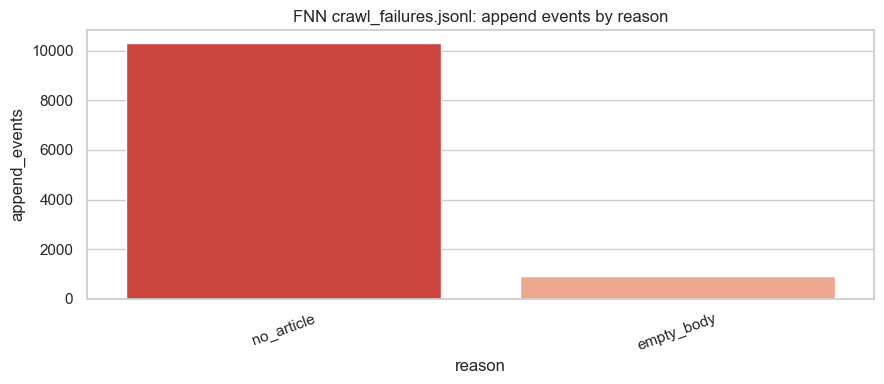

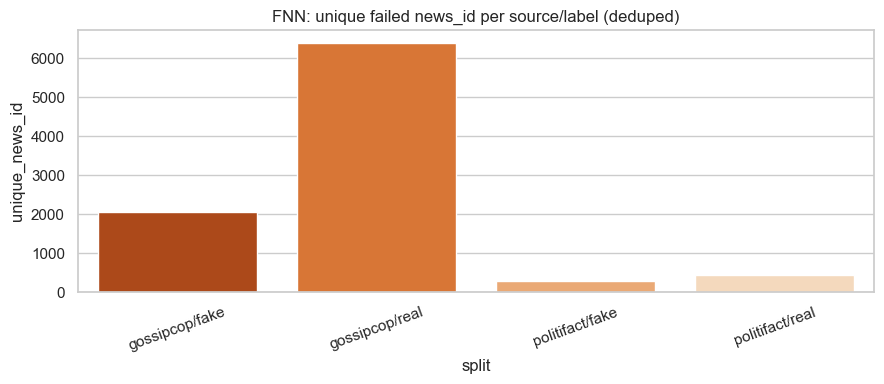

In [9]:
if len(fail_summary):
    fig, ax = plt.subplots()
    sns.barplot(data=fail_summary, x="reason", y="append_events", ax=ax, hue="reason", palette="Reds_r", legend=False)
    ax.set_title("FNN crawl_failures.jsonl: append events by reason")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

    if len(split_fail_df):
        fig, ax = plt.subplots()
        sns.barplot(data=split_fail_df, x="split", y="unique_news_id", ax=ax, hue="split", palette="Oranges_r", legend=False)
        ax.set_title("FNN: unique failed news_id per source/label (deduped)")
        plt.xticks(rotation=20)
        plt.tight_layout()
        plt.show()

## 4. Fakeddit — source TSV preprocessing stats

Scans **`multimodal_only_samples/*.tsv`** in chunks (large files). Reports per file:

- Row count  
- Missing / blank **`image_url`**  
- **`hasImage`** distribution (as strings in file)  
- Missing **`clean_title`** (if column exists)

In [10]:
FAKE_META = ROOT / "data" / "processed" / "fakeddit" / "v2_text_metadata"
MM_DIR = FAKE_META / "multimodal_only_samples"
mm_files = [
    ("train", MM_DIR / "multimodal_train.tsv"),
    ("validation", MM_DIR / "multimodal_validate.tsv"),
    ("test", MM_DIR / "multimodal_test_public.tsv"),
]

def scan_fakeddit_tsv(path: Path, chunksize: int = 80_000):
    if not path.is_file():
        return None
    rows = 0
    blank_url = 0
    na_url = 0
    has_img_counts = Counter()
    blank_title = 0
    na_title = 0
    for chunk in pd.read_csv(path, sep="\t", chunksize=chunksize, dtype=str, on_bad_lines="warn"):
        rows += len(chunk)
        if "image_url" in chunk.columns:
            s = chunk["image_url"]
            na_url += int(s.isna().sum())
            blank_url += int(s.fillna("").astype(str).str.strip().eq("").sum())
        if "hasImage" in chunk.columns:
            for v in chunk["hasImage"].fillna("(null)").astype(str):
                has_img_counts[v] += 1
        if "clean_title" in chunk.columns:
            t = chunk["clean_title"]
            na_title += int(t.isna().sum())
            blank_title += int(t.fillna("").astype(str).str.strip().eq("").sum())
    return {
        "rows": rows,
        "image_url_na": na_url,
        "image_url_blank": blank_url,
        "image_url_missing_rate": (na_url + blank_url) / rows if rows else 0,
        "hasImage_top": dict(has_img_counts.most_common(8)),
        "clean_title_na": na_title,
        "clean_title_blank": blank_title,
    }

fd_stats = []
for split_name, fp in mm_files:
    r = scan_fakeddit_tsv(fp)
    if r is None:
        fd_stats.append({"split_file": split_name, "path": str(fp), "status": "missing"})
    else:
        fd_stats.append({"split_file": split_name, "path": str(fp), **r, "status": "ok"})

fd_df = pd.DataFrame(fd_stats)
display(fd_df)

,split_file,path,rows,image_url_na,image_url_blank,image_url_missing_rate,hasImage_top,clean_title_na,clean_title_blank,status
0,train,c:\Users\mpcon\MSC Project\data\processed\fake...,564000,1534,1534,0.005440,{'True': 564000},0,0,ok
1,validation,c:\Users\mpcon\MSC Project\data\processed\fake...,59342,173,173,0.005831,{'True': 59342},0,0,ok
2,test,c:\Users\mpcon\MSC Project\data\processed\fake...,59319,156,156,0.005260,{'True': 59319},0,0,ok


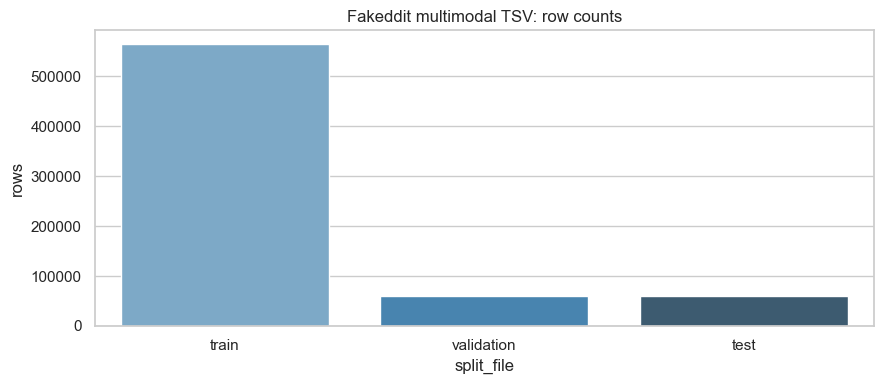

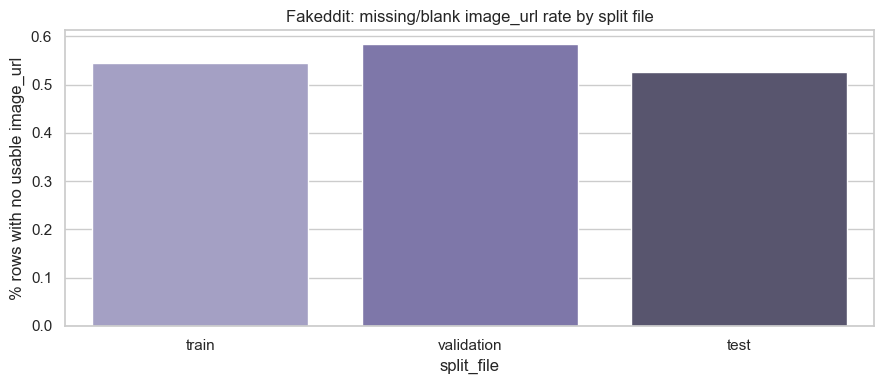

In [11]:
ok = fd_df[fd_df["status"] == "ok"]
if len(ok):
    fig, ax = plt.subplots()
    x = ok["split_file"]
    sns.barplot(x=x, y=ok["rows"].astype(float), ax=ax, hue=x, palette="Blues_d", legend=False)
    ax.set_title("Fakeddit multimodal TSV: row counts")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots()
    sns.barplot(x=x, y=ok["image_url_missing_rate"].astype(float) * 100, ax=ax, hue=x, palette="Purples_d", legend=False)
    ax.set_ylabel("% rows with no usable image_url")
    ax.set_title("Fakeddit: missing/blank image_url rate by split file")
    plt.tight_layout()
    plt.show()

## 5. Cross-check: `fakenews.tsv` FNN row count vs crawl tree

The consolidated file **drops** FNN keys that appear in the failure log (see `04_consolidate_fakenews_tsv.py`). Compare:

In [12]:
fnn_in_tsv = df[df["dataset"] == "fakenewsnet"]
n_tsv = len(fnn_in_tsv)
n_json = int(fnn_index_df["succeeded_json"].sum())
print("FNN rows in fakenews.tsv:", n_tsv)
print("FNN news content.json files on disk:", n_json)
print("Difference (typically: rows excluded via failure-log filter):", n_json - n_tsv)

FNN rows in fakenews.tsv: 14015
FNN news content.json files on disk: 14148
Difference (typically: rows excluded via failure-log filter): 133


## 6. Image acquisition — working TSV and on-disk checks

After **`pipeline/06_cohort_fetch_images.py`** (or another image-fetch step), the **working copy** may be **`data/processed/images/fakenews.tsv`** (canonical **`data/fakenews.tsv`** is not modified). Summaries below use **`df`** when it already includes fetch columns; otherwise they load the working TSV. **`image_progress.jsonl`** is append-only (one JSON object per HTTP attempt). **SHA-256 blocklist** placeholders appear as **`image_geo_blocked`** / failed fetch with **`blocked_sha256`** in logs.

**Dependencies:** `Pillow` for thumbnails (optional cell).


In [ ]:
IMG_DIR = ROOT / "data" / "processed" / "images"
WORK_TSV = IMG_DIR / "fakenews.tsv"
PROGRESS_JSONL = IMG_DIR / "image_progress.jsonl"

def _norm_bool_series(s):
    if s is None:
        return None
    return s.astype(str).str.strip().str.lower()

# Prefer columns on main dataframe if present (from working TSV load)
cols_needed = {"image_local_path", "image_download_ok", "image_geo_blocked"}
if not cols_needed.issubset(set(df.columns)):
    if WORK_TSV.is_file():
        print("Loading fetch columns from", WORK_TSV)
        dfi = pd.read_csv(
            WORK_TSV,
            sep="\t",
            dtype=str,
            low_memory=False,
            usecols=lambda c: c
            in (
                "dataset",
                "sample_id",
                "has_image_ref",
                "image_ref",
                "image_local_path",
                "image_download_ok",
                "image_geo_blocked",
            ),
        )
    else:
        dfi = None
        print(
            "No working TSV at",
            WORK_TSV,
            "— run cohort image fetch (e.g. `06_cohort_fetch_images.py`) or load consolidated file with fetch columns.",
        )
else:
    dfi = df
    print("Using fetch columns from notebook `df`.")

if dfi is not None:
    hr = _norm_bool_series(dfi.get("has_image_ref"))
    ok = _norm_bool_series(dfi.get("image_download_ok"))
    geo = _norm_bool_series(dfi.get("image_geo_blocked"))
    with_ref = hr == "true"
    print("Rows with has_image_ref=true:", int(with_ref.sum()))
    print(
        "image_download_ok (of rows with ref):",
        ok[with_ref].value_counts(dropna=False).head(10).to_string(),
    )
    print(
        "image_geo_blocked (of rows with ref):",
        geo[with_ref].value_counts(dropna=False).head(10).to_string(),
    )
    by_ds = dfi.loc[with_ref].groupby("dataset")["image_download_ok"].apply(
        lambda s: (s.astype(str).str.lower() == "true").sum()
    )
    print("Download OK count by dataset (has_image_ref=true):\n", by_ds.to_string())
    lp = dfi.loc[with_ref, "image_local_path"].fillna("").astype(str).str.strip()
    nonempty = lp.str.len() > 0
    print("Rows with non-empty image_local_path:", int(nonempty.sum()))

if PROGRESS_JSONL.is_file():
    n_prog = sum(1 for _ in open(PROGRESS_JSONL, encoding="utf-8"))
    print("image_progress.jsonl lines:", n_prog)
else:
    print("No image_progress.jsonl yet.")

# File existence sample (rows marked ok)
if dfi is not None and "image_local_path" in dfi.columns:
    ok_mask = (
        with_ref
        & (ok == "true")
        & (dfi["image_local_path"].fillna("").astype(str).str.strip().str.len() > 0)
    )
    sample = dfi.loc[ok_mask].head(5000)
    exists = 0
    missing = 0
    sizes = []
    for _, r in sample.iterrows():
        rel = str(r["image_local_path"]).replace("\\", "/")
        p = (ROOT / rel).resolve()
        try:
            p.relative_to(ROOT.resolve())
        except ValueError:
            missing += 1
            continue
        if p.is_file():
            exists += 1
            try:
                sizes.append(p.stat().st_size)
            except OSError:
                pass
        else:
            missing += 1
    print(
        f"Sample file check (up to 5000 rows marked download ok): exists={exists}, missing_path={missing}"
    )
    if sizes:
        fig, ax = plt.subplots()
        ax.hist(sizes, bins=40, color="steelblue", edgecolor="white")
        ax.set_xlabel("File size (bytes)")
        ax.set_ylabel("Count")
        ax.set_title("On-disk image sizes (sample of rows with image_download_ok=true)")
        plt.tight_layout()
        plt.show()


In [ ]:
# Optional: show a few thumbnails (requires Pillow)
try:
    from PIL import Image
except ImportError:
    print("Install Pillow for thumbnails: pip install Pillow")
else:
    if dfi is None:
        print("No dataframe with paths.")
    else:
        ok_mask = with_ref & (ok == "true")
        cand = dfi.loc[
            ok_mask & dfi["image_local_path"].fillna("").astype(str).str.strip().str.ne("")
        ]
        if len(cand) == 0:
            print("No rows with paths to display.")
        else:
            cand = cand.sample(n=min(6, len(cand)), random_state=42)
            fig, axes = plt.subplots(2, 3, figsize=(10, 7))
            axes = axes.ravel()
            for ax, (_, r) in zip(axes, cand.iterrows()):
                rel = str(r["image_local_path"]).replace("\\", "/")
                p = (ROOT / rel).resolve()
                sid = str(r["sample_id"])
                title = sid[:18] + "…" if len(sid) > 18 else sid
                if p.is_file():
                    try:
                        im = Image.open(p).convert("RGB")
                        ax.imshow(im)
                        ax.set_title(title, fontsize=8)
                    except OSError:
                        ax.text(0.5, 0.5, "read err", ha="center")
                else:
                    ax.text(0.5, 0.5, "missing", ha="center")
                ax.axis("off")
            for j in range(len(cand), len(axes)):
                axes[j].axis("off")
            plt.suptitle("Sample images (image_download_ok=true)")
            plt.tight_layout()
            plt.show()
